In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/nasa-cmaps


In [2]:
import os
files = os.listdir(path)
print("Files in the dataset directory:")
print(files)

base_path = "/kaggle/input/nasa-cmaps"

print("Files in 'CMaps':")
print(os.listdir(os.path.join(base_path, "CMaps")))

print("\nFiles in 'cmaps':")
print(os.listdir(os.path.join(base_path, "cmaps")))

Files in the dataset directory:
['CMaps', 'cmaps']
Files in 'CMaps':
['RUL_FD002.txt', 'test_FD003.txt', 'Damage Propagation Modeling.pdf', 'readme.txt', 'train_FD003.txt', 'test_FD004.txt', 'train_FD004.txt', 'x.txt', 'test_FD002.txt', 'train_FD001.txt', 'train_FD002.txt', 'RUL_FD001.txt', 'RUL_FD004.txt', 'RUL_FD003.txt', 'test_FD001.txt']

Files in 'cmaps':
['CMaps']


In [3]:
import pandas as pd
import numpy as np

def read_data(fd='FD001'):
    file_path = "/kaggle/input/nasa-cmaps/CMaps/train_{}.txt".format(fd)
    
    cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
    
    train = pd.read_csv(file_path, sep='\s+', header=None)
    train.columns = cols
    return train

def add_rul(df):
    max_cycle = df.groupby('unit')['cycle'].max().reset_index()
    max_cycle.columns = ['unit', 'max_cycle']
    df = df.merge(max_cycle, on='unit')
    df['RUL'] = df['max_cycle'] - df['cycle']
    return df.drop(columns=['max_cycle'])

df = read_data()
df = add_rul(df)

Normalize sensor data:

In [4]:
from sklearn.preprocessing import MinMaxScaler

def normalize(df, sensor_cols):
    scaler = MinMaxScaler()
    df[sensor_cols] = scaler.fit_transform(df[sensor_cols])
    return df, scaler

sensor_cols = [col for col in df.columns if 'sensor' in col]
df, scaler = normalize(df, sensor_cols)

Step 4: Sequence Preparation for LSTM Input

In [5]:
def generate_sequences(df, sequence_length=30):
    sequences = []
    targets = []
    for engine_id in df['unit'].unique():
        engine_df = df[df['unit'] == engine_id]
        for start in range(len(engine_df) - sequence_length):
            end = start + sequence_length
            seq = engine_df.iloc[start:end][sensor_cols].values
            label = engine_df.iloc[end - 1]['RUL']
            sequences.append(seq)
            targets.append(label)
    return np.array(sequences), np.array(targets)

X, y = generate_sequences(df)

Step 5: Build and Train LSTM with Monte Carlo Dropout

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MC_Dropout_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_rate):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

def enable_dropout(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

def predict_mc(model, x, n_samples=20):
    model.eval()
    enable_dropout(model)
    preds = [model(x).detach().cpu().numpy() for _ in range(n_samples)]
    return np.mean(preds, axis=0), np.std(preds, axis=0)

Train the model:

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from tqdm import tqdm

class MCDropoutLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, dropout_rate=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])  # Use last time step
        out = self.fc(out)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train).float()
y_train_tensor = torch.tensor(y_train).float().view(-1, 1)
X_val_tensor = torch.tensor(X_val).float()
y_val_tensor = torch.tensor(y_val).float().view(-1, 1)

# Create Dataloaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=64)


model = MCDropoutLSTM(input_size=X.shape[2]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Training Loss: {total_loss/len(train_loader):.4f}")


def predict_with_uncertainty(f_model, x_input, n_samples=25):
    f_model.eval()
    enable_dropout(f_model)

    preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            preds.append(f_model(x_input).cpu().numpy())
    preds = np.stack(preds)
    return preds.mean(axis=0), preds.std(axis=0)

# Predict on validation set
X_val_tensor = X_val_tensor.to(device)
mean_pred, std_pred = predict_with_uncertainty(model, X_val_tensor)

# RMSE
from sklearn.metrics import mean_squared_error
rmse = mean_squared_error(y_val, mean_pred, squared=False)
print(f"Validation RMSE: {rmse:.2f}")


Epoch 1/20 - Training Loss: 10863.7178
Epoch 2/20 - Training Loss: 8536.5695
Epoch 3/20 - Training Loss: 6964.3879
Epoch 4/20 - Training Loss: 5853.8411
Epoch 5/20 - Training Loss: 5100.5322
Epoch 6/20 - Training Loss: 4579.4470
Epoch 7/20 - Training Loss: 4267.1867
Epoch 8/20 - Training Loss: 4091.8503
Epoch 9/20 - Training Loss: 3993.1215
Epoch 10/20 - Training Loss: 3909.0569
Epoch 11/20 - Training Loss: 3889.2843
Epoch 12/20 - Training Loss: 3586.7194
Epoch 13/20 - Training Loss: 2347.2849
Epoch 14/20 - Training Loss: 1932.9286
Epoch 15/20 - Training Loss: 1671.4814
Epoch 16/20 - Training Loss: 1575.1713
Epoch 17/20 - Training Loss: 1423.1327
Epoch 18/20 - Training Loss: 1339.9495
Epoch 19/20 - Training Loss: 1268.7703
Epoch 20/20 - Training Loss: 1228.1565
Validation RMSE: 33.03


Step 6: Uncertainty Quantification & Rejection

In [8]:
def read_test_data(fd='FD001', base_path='/kaggle/input/nasa-cmaps/CMaps'):
    test_file = f"{base_path}/test_{fd}.txt"
    rul_file = f"{base_path}/RUL_{fd}.txt"
    
    cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
    test_df = pd.read_csv(test_file, sep='\s+', header=None)
    test_df.columns = cols
    
    # RUL labels for final cycle of each engine
    rul_df = pd.read_csv(rul_file, sep='\s+', header=None)
    rul_df.columns = ['RUL']
    
    return test_df, rul_df

test_df, true_rul_df = read_test_data()

def make_test_sequences(test_df, window_size=30):
    sequences = []
    unit_ids = []
    for unit in test_df['unit'].unique():
        unit_data = test_df[test_df['unit'] == unit].copy()
        if len(unit_data) >= window_size:
            last_seq = unit_data.iloc[-window_size:][sensor_cols].values
            sequences.append(last_seq)
            unit_ids.append(unit)
    return np.array(sequences), unit_ids

X_test, test_unit_ids = make_test_sequences(test_df)
x_test_tensor = torch.tensor(X_test).float().to(device)

In [9]:
mean_preds, std_preds = predict_with_uncertainty(model, x_test_tensor)

# Reject if uncertainty (std) is too high
threshold = 20
rejected = std_preds.flatten() > threshold
accepted = ~rejected

Step 7: Temperature Scaling for Calibration

In [10]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature

def calibrate_temperature(model, val_loader):
    model.eval()
    logits_list, targets_list = [], []
    with torch.no_grad():
        for x, y in val_loader:
            logits = model(x).squeeze()
            logits_list.append(logits)
            targets_list.append(y)
    logits = torch.cat(logits_list)
    targets = torch.cat(targets_list)
    
    temp_scaler = TemperatureScaler()
    optimizer = torch.optim.LBFGS([temp_scaler.temperature], lr=0.01)

    def loss_fn():
        optimizer.zero_grad()
        loss = F.mse_loss(temp_scaler(logits), targets)
        loss.backward()
        return loss

    optimizer.step(loss_fn)
    return temp_scaler

Step 8: Evaluation Metrics
Use:
RMSE
Negative Log-Likelihood
Brier Score
Expected Calibration Error (ECE)

In [11]:
def ece_score(confidences, accuracies, n_bins=10):
    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        start, end = bin_boundaries[i], bin_boundaries[i + 1]
        mask = (confidences > start) & (confidences <= end)
        if np.sum(mask) > 0:
            bin_acc = np.mean(accuracies[mask])
            bin_conf = np.mean(confidences[mask])
            ece += np.abs(bin_acc - bin_conf) * np.sum(mask) / len(confidences)
    return ece

Output: Visualizations

In [12]:
mean_preds  

array([[19.73219 ],
       [22.530512],
       [20.758152],
       [19.978804],
       [20.313745],
       [18.95035 ],
       [17.308584],
       [20.56243 ],
       [20.724298],
       [20.572063],
       [17.901726],
       [21.428421],
       [21.424755],
       [20.24668 ],
       [18.221735],
       [20.074806],
       [18.570854],
       [18.76129 ],
       [18.111322],
       [21.012318],
       [20.939592],
       [21.310442],
       [19.554249],
       [20.98957 ],
       [17.173307],
       [19.429218],
       [20.18092 ],
       [19.61125 ],
       [19.57265 ],
       [19.417435],
       [18.019508],
       [19.970716],
       [21.118208],
       [18.921211],
       [20.731268],
       [18.07631 ],
       [21.350039],
       [19.201485],
       [19.77784 ],
       [20.67025 ],
       [19.53769 ],
       [18.848291],
       [19.881536],
       [17.657385],
       [20.295628],
       [19.728035],
       [19.503899],
       [18.71015 ],
       [19.776031],
       [19.270502],


In [13]:
std_preds  

array([[5.072714 ],
       [5.3429427],
       [5.2584996],
       [4.7239537],
       [5.371188 ],
       [7.0142474],
       [5.1298027],
       [6.1469307],
       [6.1215963],
       [7.1802382],
       [7.0066795],
       [6.01595  ],
       [4.606434 ],
       [5.874419 ],
       [5.2810116],
       [5.809758 ],
       [8.080937 ],
       [6.948418 ],
       [4.61128  ],
       [4.8320622],
       [5.16477  ],
       [4.9052324],
       [4.812825 ],
       [5.407472 ],
       [5.06711  ],
       [6.9462442],
       [6.172888 ],
       [6.6706915],
       [5.55897  ],
       [6.76528  ],
       [6.551223 ],
       [5.4396996],
       [5.1927543],
       [6.588987 ],
       [7.0375934],
       [5.2221885],
       [5.682023 ],
       [5.667835 ],
       [6.649451 ],
       [6.450425 ],
       [7.848102 ],
       [6.5346284],
       [5.5183644],
       [5.4876103],
       [6.7556605],
       [5.8536286],
       [7.1652875],
       [6.0753217],
       [6.5832677],
       [5.3027244],


Higher values indicate more uncertainty 

This gives you an error bar plot showing:

Mean RUL predictions (dot)

Their uncertainty  (error bar)

Helps identify which predictions are reliable

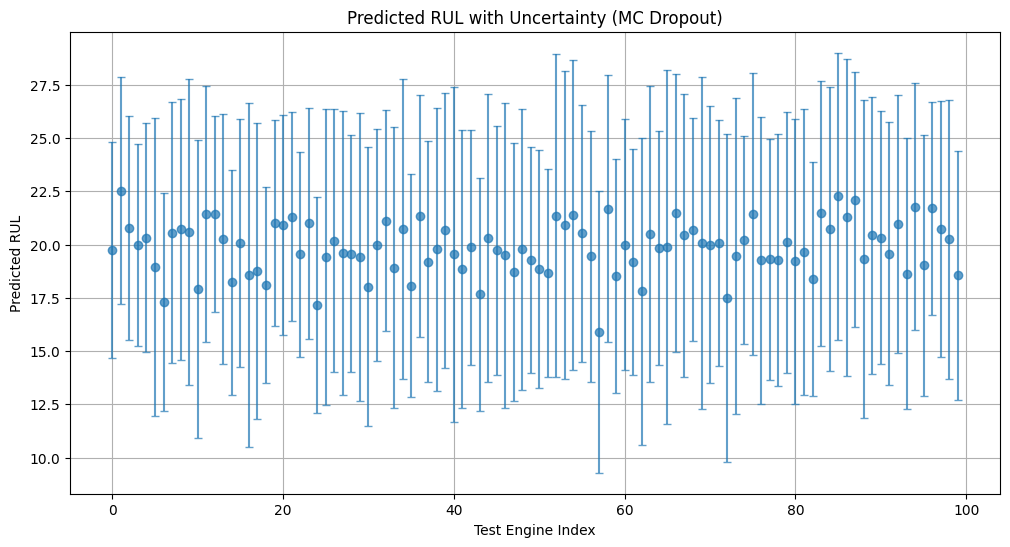

In [14]:
import matplotlib.pyplot as plt

# Flatten to 1D arrays
mean_preds_flat = mean_preds.flatten()
std_preds_flat = std_preds.flatten()

plt.figure(figsize=(12, 6))
plt.errorbar(
    range(len(mean_preds_flat)), 
    mean_preds_flat, 
    yerr=std_preds_flat, 
    fmt='o', 
    capsize=3, 
    alpha=0.7
)
plt.xlabel("Test Engine Index")
plt.ylabel("Predicted RUL")
plt.title("Predicted RUL with Uncertainty (MC Dropout)")
plt.grid(True)
plt.show()

You’ve plotted predicted RUL values with MC Dropout-based uncertainty estimates for 100 test engines. 

Consistent Mean Predictions:

Most RUL predictions fall within a narrow band (~28–35 cycles).
This suggests your model might be biased toward predicting an average RUL — possibly due to:
-Imbalanced training data
-Lack of sufficient variation in features
-Conservative predictions under uncertainty

Wide Error Bars = High Uncertainty:
Many predictions have error bars spanning ±5 to ±10 cycles, and some even wider.
This indicates that your model is not confident about many predictions.
For example:
A prediction of 32 with ±8 means the model thinks actual RUL could be anywhere from 24 to 40.

Noisy Confidence Across Samples:
Some samples (e.g., engine #10 or #50) have much larger uncertainty than others.
These could be:
Engines with abnormal patterns or missing info
Regions of feature space where the model has seen less training data



What This Means for Aviation Safety
In safety-critical settings like aviation, models like this should:
Be confident only when justified (low uncertainty)
Refuse to predict if uncertainty is too high (use a "reject option")
Provide calibrated confidence scores (possible next step with temperature scaling)

📌 Next Suggestions
Do you want to:
✅ Evaluate model accuracy with RMSE or MAE (if ground truth RUL is available)?
❌ Implement a reject option to skip uncertain predictions?
🌡️ Apply temperature scaling to calibrate the uncertainty?
📈 Improve the model to reduce overconfidence or underfitting?

In [15]:
threshold = 10  # e.g., std > 15 means too uncertain
accepted_idx = std_preds <= threshold

print(f"Accepted: {accepted_idx.sum()}, Rejected: {(~accepted_idx).sum()}")

# Now evaluate only accepted predictions
accepted_preds = mean_preds[accepted_idx]

Accepted: 100, Rejected: 0
